# Notebook 25 - Alpha peak and mask diagnostics

Goal: understand why the current Python `dohough + weighted_median` alpha from notebook 23 is still not numerically close enough to MATLAB `Fdat.geofeatures.alpha`.

This notebook does **not** modify `ultrasound_tracker`. It is a diagnostic notebook. The main question is:

1. Does the Python Hough peak list contain a peak near MATLAB alpha?
2. If yes, why does the weighted median choose another peak?
3. If no, is the current Python fascicle mask/Hough accumulator missing MATLAB's dominant angle?
4. Is the integer-degree Python Hough grid part of the remaining error?

In [1]:
from pathlib import Path
import importlib
from typing import Mapping

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

import ultrasound_tracker.roi as roi
from ultrasound_tracker.legacy.frangi_detector import FrangiDetector
from ultrasound_tracker.matlab_compat import (
    compute_metrics,
    extract_geofeature_arrays,
    get_nested,
    load_matlab_result,
)
from ultrasound_tracker.timtrack_hough import DoHoughParams, dohough, weighted_median

roi = importlib.reload(roi)

plt.style.use("default")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/grosbedou/PycharmProjects/NDORMS


## 1. Load the same MATLAB and Python results

Notebook 23 is the current best sequence run: the fascicle angle is no longer the selected OpenCV line angle; it is the MATLAB-style `dohough` weighted median applied to the current Python Frangi fascicle mask.

In [2]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
MATLAB_RESULT = PROJECT_ROOT / "data" / "matlab" / "slow_low_01_DOWN_tracked_Q=001.mat"
PY23_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_dohough_alpha_features_arrays.npz"

OUT_DIR = PROJECT_ROOT / "results" / "matlab_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIAGNOSTICS_CSV = OUT_DIR / "notebook25_alpha_peak_diagnostics.csv"
OUT_METRICS_CSV = OUT_DIR / "notebook25_alpha_peak_metrics.csv"
OUT_NPZ = OUT_DIR / "notebook25_alpha_peak_arrays.npz"

for path in [VIDEO_PATH, ROI_PATH, MATLAB_RESULT, PY23_NPZ]:
    print(path, "exists=", path.exists())

rois = roi.load_rois(ROI_PATH)
mat = load_matlab_result(MATLAB_RESULT)
matlab_geo = extract_geofeature_arrays(mat)
py23 = np.load(PY23_NPZ)

print("ROIs:", rois)
print("MATLAB alpha frames:", len(matlab_geo["alpha_deg"]))
print("Python notebook 23 frames:", len(py23["fascicle_angle_deg"]))

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json exists= True
/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat exists= True
/Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_dohough_alpha_features_arrays.npz exists= True
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}
MATLAB alpha frames: 2666
Python notebook 23 frames: 2667


## 2. Extract MATLAB and Python Hough peaks

MATLAB stores the peak angles and peak weights in `Fdat.geofeatures.alphas` and `Fdat.geofeatures.ws`. Notebook 23 stores the equivalent Python arrays as `dohough_peak_alphas` and `dohough_peak_weights`.

This lets us separate three things:

- the final weighted-median alpha,
- the first/strongest Hough peak,
- the best possible match inside the available peak list.

In [3]:
def as_geofeature_entries(obj):
    if isinstance(obj, Mapping):
        return [obj]
    if isinstance(obj, (list, tuple)):
        return list(obj)
    return list(np.asarray(obj, dtype=object).reshape(-1))


def peak_matrix(entries, key, n_cols=10, fill=np.nan):
    out = np.full((len(entries), n_cols), fill, dtype=np.float64)
    for i, entry in enumerate(entries):
        if not isinstance(entry, Mapping) or key not in entry:
            continue
        values = np.asarray(entry[key], dtype=np.float64).reshape(-1)
        n = min(n_cols, len(values))
        out[i, :n] = values[:n]
    return out


def weighted_median_rows(values, weights):
    out = np.full(values.shape[0], np.nan, dtype=np.float64)
    for i in range(values.shape[0]):
        v = values[i]
        w = weights[i]
        mask = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if np.any(mask):
            out[i] = weighted_median(v[mask], w[mask])
    return out


def nearest_peak(peaks, target):
    target = np.asarray(target, dtype=np.float64)
    nearest_value = np.full(len(target), np.nan, dtype=np.float64)
    nearest_dist = np.full(len(target), np.nan, dtype=np.float64)
    nearest_index = np.full(len(target), -1, dtype=np.int32)

    for i in range(len(target)):
        row = np.asarray(peaks[i], dtype=np.float64)
        mask = np.isfinite(row) & np.isfinite(target[i])
        if not np.any(mask):
            continue
        valid_indices = np.flatnonzero(mask)
        d = np.abs(row[mask] - target[i])
        j_local = int(np.argmin(d))
        j = int(valid_indices[j_local])
        nearest_value[i] = row[j]
        nearest_dist[i] = d[j_local]
        nearest_index[i] = j
    return nearest_value, nearest_dist, nearest_index


def weighted_spread(values, weights, center):
    out = np.full(values.shape[0], np.nan, dtype=np.float64)
    for i in range(values.shape[0]):
        v = values[i]
        w = weights[i]
        c = center[i]
        mask = np.isfinite(v) & np.isfinite(w) & (w > 0) & np.isfinite(c)
        if not np.any(mask):
            continue
        ww = w[mask]
        out[i] = np.sum(ww * np.abs(v[mask] - c)) / np.sum(ww)
    return out


def half_degree_fraction(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    doubled = np.round(values * 2.0)
    is_half = np.isclose(np.mod(doubled, 2), 1)
    return float(np.mean(is_half))


def metric_row(name, reference, estimate):
    row = {"comparison": name}
    row.update(compute_metrics(reference, estimate))
    return row

entries = as_geofeature_entries(get_nested(mat, "Fdat.geofeatures"))
mat_peak_alphas = peak_matrix(entries, "alphas", n_cols=10)
mat_peak_weights = peak_matrix(entries, "ws", n_cols=10)

n = min(
    len(matlab_geo["alpha_deg"]),
    len(py23["fascicle_angle_deg"]),
    len(mat_peak_alphas),
    len(py23["dohough_peak_alphas"]),
)

frames = np.asarray(py23["frame"][:n], dtype=np.int32)
mat_alpha = np.asarray(matlab_geo["alpha_deg"][:n], dtype=np.float64)
py_alpha = np.asarray(py23["fascicle_angle_deg"][:n], dtype=np.float64)
selected_line_alpha = np.asarray(py23["selected_line_angle_deg"][:n], dtype=np.float64)
mask_density = np.asarray(py23["dohough_mask_density"][:n], dtype=np.float64)
n_candidates = np.asarray(py23["n_fascicle_candidates"][:n], dtype=np.float64)

mat_peak_alphas = mat_peak_alphas[:n]
mat_peak_weights = mat_peak_weights[:n]
py_peak_alphas = np.asarray(py23["dohough_peak_alphas"][:n], dtype=np.float64)
py_peak_weights = np.asarray(py23["dohough_peak_weights"][:n], dtype=np.float64)

mat_alpha_from_peaks = weighted_median_rows(mat_peak_alphas, mat_peak_weights)
py_alpha_from_peaks = weighted_median_rows(py_peak_alphas, py_peak_weights)

py_nearest_to_mat, py_nearest_dist, py_nearest_index = nearest_peak(py_peak_alphas, mat_alpha)
mat_nearest_to_py, mat_nearest_dist, mat_nearest_index = nearest_peak(mat_peak_alphas, py_alpha)

mat_first_peak = mat_peak_alphas[:, 0]
py_first_peak = py_peak_alphas[:, 0]
mat_first_weight = mat_peak_weights[:, 0]
py_first_weight = py_peak_weights[:, 0]
mat_total_weight = np.nansum(mat_peak_weights, axis=1)
py_total_weight = np.nansum(py_peak_weights, axis=1)

mat_spread = weighted_spread(mat_peak_alphas, mat_peak_weights, mat_alpha)
py_spread = weighted_spread(py_peak_alphas, py_peak_weights, py_alpha)

print("Aligned frame count:", n)
print("First/last Python frame:", frames[0], frames[-1])

Aligned frame count: 2666
First/last Python frame: 0 2665


## 3. Numeric summary

The key diagnostic is the row called **nearest Python peak to MATLAB alpha**. If this row is much better than the current Python alpha, the mask/Hough peak set often contains the right answer, but the peak weights and weighted median are choosing another angle.

In [4]:
metrics = pd.DataFrame([
    metric_row("alpha: Python notebook23 weighted median", mat_alpha, py_alpha),
    metric_row("alpha: selected OpenCV line angle", mat_alpha, selected_line_alpha),
    metric_row("alpha: nearest Python peak to MATLAB alpha", mat_alpha, py_nearest_to_mat),
    metric_row("alpha: Python first/strongest peak", mat_alpha, py_first_peak),
    metric_row("alpha: MATLAB weightedMedian(MATLAB peaks/ws)", mat_alpha, mat_alpha_from_peaks),
    metric_row("alpha: Python weightedMedian(Python peaks/ws)", py_alpha, py_alpha_from_peaks),
    metric_row("alpha: MATLAB first/strongest peak", mat_alpha, mat_first_peak),
    metric_row("alpha: nearest MATLAB peak to Python alpha", py_alpha, mat_nearest_to_py),
])

metrics.to_csv(OUT_METRICS_CSV, index=False)
display(metrics)
print("Saved metrics:", OUT_METRICS_CSV)

,comparison,n,bias,mae,rmse,corr
0,alpha: Python notebook23 weighted median,2666,2.319392,2.526819,3.537244,0.866061
1,alpha: selected OpenCV line angle,2666,-11.390793,11.659603,18.967960,-0.096262
2,alpha: nearest Python peak to MATLAB alpha,2666,0.253751,0.593586,1.098019,0.980453
3,alpha: Python first/strongest peak,2666,3.210240,3.488185,4.628034,0.781362
4,alpha: MATLAB weightedMedian(MATLAB peaks/ws),2666,0.000000,0.000000,0.000000,1.000000
5,alpha: Python weightedMedian(Python peaks/ws),2666,0.000000,0.000000,0.000000,1.000000
6,alpha: MATLAB first/strongest peak,2666,-0.537884,2.575769,5.172711,0.646266
7,alpha: nearest MATLAB peak to Python alpha,2666,-0.217929,0.470743,0.728402,0.990859


Saved metrics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook25_alpha_peak_metrics.csv


In [5]:
alpha_error = py_alpha - mat_alpha
abs_alpha_error = np.abs(alpha_error)
nearest_error = py_nearest_to_mat - mat_alpha

category = np.full(n, "matched within 1 deg", dtype=object)
category[(abs_alpha_error > 1.0) & (py_nearest_dist <= 1.0)] = "peak exists, weighted median differs"
category[(abs_alpha_error > 1.0) & (py_nearest_dist > 1.0)] = "nearest Python peak also far"
category[(~np.isfinite(abs_alpha_error)) | (~np.isfinite(py_nearest_dist))] = "missing data"

summary_table = pd.DataFrame({
    "quantity": [
        "Python alpha MAE vs MATLAB",
        "Nearest Python peak MAE vs MATLAB",
        "Median nearest Python peak distance",
        "Frames with Python alpha <= 1 deg error",
        "Frames with a Python peak <= 1 deg from MATLAB",
        "MATLAB alpha values on half-degree grid",
        "MATLAB peak angles on half-degree grid",
        "Python peak angles on half-degree grid",
    ],
    "value": [
        float(np.nanmean(abs_alpha_error)),
        float(np.nanmean(np.abs(nearest_error))),
        float(np.nanmedian(py_nearest_dist)),
        float(np.nanmean(abs_alpha_error <= 1.0)),
        float(np.nanmean(py_nearest_dist <= 1.0)),
        half_degree_fraction(mat_alpha),
        half_degree_fraction(mat_peak_alphas),
        half_degree_fraction(py_peak_alphas),
    ],
})

display(summary_table)

display(pd.Series(category).value_counts(dropna=False).rename_axis("diagnostic category").reset_index(name="frames"))

display(Markdown(f"""
**Interpretation checkpoint**

- Python weighted-median alpha MAE is **{np.nanmean(abs_alpha_error):.3f} deg**.
- The nearest Python Hough peak to MATLAB alpha has MAE **{np.nanmean(np.abs(nearest_error)):.3f} deg**.
- **{100*np.nanmean(py_nearest_dist <= 1.0):.1f}%** of frames have at least one Python peak within 1 deg of MATLAB alpha.
- **{100*half_degree_fraction(mat_peak_alphas):.1f}%** of MATLAB stored peak angles are half-degree values, while Python notebook 23 peaks are on the integer-degree grid.

So the current problem is not simply “Python never sees the MATLAB angle.” In many frames it sees a nearby angle, but the weighted peak distribution chooses a slightly higher alpha.
"""))

,quantity,value
0,Python alpha MAE vs MATLAB,2.526819
1,Nearest Python peak MAE vs MATLAB,0.593586
2,Median nearest Python peak distance,0.500000
3,Frames with Python alpha <= 1 deg error,0.323331
4,Frames with a Python peak <= 1 deg from MATLAB,0.897974
5,MATLAB alpha values on half-degree grid,0.501500
6,MATLAB peak angles on half-degree grid,0.505926
7,Python peak angles on half-degree grid,0.000000


,diagnostic category,frames
0,"peak exists, weighted median differs",1532
1,matched within 1 deg,862
2,nearest Python peak also far,272



**Interpretation checkpoint**

- Python weighted-median alpha MAE is **2.527 deg**.
- The nearest Python Hough peak to MATLAB alpha has MAE **0.594 deg**.
- **89.8%** of frames have at least one Python peak within 1 deg of MATLAB alpha.
- **50.6%** of MATLAB stored peak angles are half-degree values, while Python notebook 23 peaks are on the integer-degree grid.

So the current problem is not simply “Python never sees the MATLAB angle.” In many frames it sees a nearby angle, but the weighted peak distribution chooses a slightly higher alpha.


## 4. Save per-frame diagnostics

This table is the map for the next correction. Large alpha error plus small nearest-peak distance points to the weighting/median/peak ranking behavior. Large alpha error plus large nearest-peak distance points to the fascicle mask or accumulator input.

In [6]:
diagnostics = pd.DataFrame({
    "row": np.arange(n, dtype=np.int32),
    "frame": frames,
    "matlab_alpha": mat_alpha,
    "python_alpha": py_alpha,
    "alpha_error_python_minus_matlab": alpha_error,
    "abs_alpha_error": abs_alpha_error,
    "selected_line_alpha": selected_line_alpha,
    "py_first_peak_alpha": py_first_peak,
    "py_first_peak_weight": py_first_weight,
    "py_total_peak_weight": py_total_weight,
    "py_weighted_peak_spread": py_spread,
    "py_nearest_peak_to_matlab": py_nearest_to_mat,
    "py_nearest_peak_distance_to_matlab": py_nearest_dist,
    "py_nearest_peak_index": py_nearest_index,
    "matlab_first_peak_alpha": mat_first_peak,
    "matlab_first_peak_weight": mat_first_weight,
    "matlab_total_peak_weight": mat_total_weight,
    "matlab_weighted_peak_spread": mat_spread,
    "matlab_nearest_peak_to_python": mat_nearest_to_py,
    "matlab_nearest_peak_distance_to_python": mat_nearest_dist,
    "matlab_nearest_peak_index": mat_nearest_index,
    "mask_density": mask_density,
    "n_fascicle_candidates": n_candidates,
    "category": category,
})

diagnostics.to_csv(OUT_DIAGNOSTICS_CSV, index=False)
np.savez(
    OUT_NPZ,
    frame=frames,
    matlab_alpha=mat_alpha,
    python_alpha=py_alpha,
    selected_line_alpha=selected_line_alpha,
    alpha_error=alpha_error,
    py_peak_alphas=py_peak_alphas,
    py_peak_weights=py_peak_weights,
    matlab_peak_alphas=mat_peak_alphas,
    matlab_peak_weights=mat_peak_weights,
    py_nearest_peak_to_matlab=py_nearest_to_mat,
    py_nearest_peak_distance_to_matlab=py_nearest_dist,
    mask_density=mask_density,
    category=category.astype(str),
)

print("Saved diagnostics:", OUT_DIAGNOSTICS_CSV)
print("Saved arrays:", OUT_NPZ)

display(diagnostics.sort_values("abs_alpha_error", ascending=False).head(12))

Saved diagnostics: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook25_alpha_peak_diagnostics.csv
Saved arrays: /Users/grosbedou/PycharmProjects/NDORMS/results/matlab_comparison/notebook25_alpha_peak_arrays.npz


,row,frame,matlab_alpha,python_alpha,alpha_error_python_minus_matlab,abs_alpha_error,selected_line_alpha,py_first_peak_alpha,py_first_peak_weight,py_total_peak_weight,py_weighted_peak_spread,py_nearest_peak_to_matlab,py_nearest_peak_distance_to_matlab,py_nearest_peak_index,matlab_first_peak_alpha,matlab_first_peak_weight,matlab_total_peak_weight,matlab_weighted_peak_spread,matlab_nearest_peak_to_python,matlab_nearest_peak_distance_to_python,matlab_nearest_peak_index,mask_density,n_fascicle_candidates,category
120,120,120,18.0,34.0,16.0,16.0,21.124718,34.0,264.0,1983.0,1.796268,25.0,7.0,7,34.0,271.0,2479.0,7.224889,34.0,0.0,0,0.066404,53.0,nearest Python peak also far
730,730,730,14.0,30.0,16.0,16.0,21.801407,29.0,296.0,2439.0,2.683067,27.0,13.0,9,28.5,299.0,2722.0,8.304739,30.0,0.0,5,0.100177,155.0,nearest Python peak also far
119,119,119,19.0,34.0,15.0,15.0,18.924643,34.0,268.0,2013.0,3.070541,20.0,1.0,6,34.5,280.0,2462.0,7.995329,34.5,0.5,0,0.069132,70.0,"peak exists, weighted median differs"
2553,2553,2553,20.5,35.0,14.5,14.5,17.354025,35.0,246.0,1889.0,4.899947,20.0,0.5,5,18.0,265.0,2548.0,8.919937,36.0,1.0,8,0.062889,53.0,"peak exists, weighted median differs"
71,71,71,12.5,27.0,14.5,14.5,21.447735,27.0,272.0,2332.0,5.292453,13.0,0.5,9,26.5,309.0,2811.0,7.059943,27.0,0.0,8,0.092998,114.0,"peak exists, weighted median differs"
1141,1141,1141,14.5,29.0,14.5,14.5,18.434948,29.0,291.0,2324.0,5.136403,13.0,1.5,4,13.5,324.0,2786.0,5.627782,29.5,0.5,6,0.090192,113.0,nearest Python peak also far
2552,2552,2552,20.5,35.0,14.5,14.5,18.434948,35.0,250.0,1931.0,4.310720,20.0,0.5,6,18.5,270.0,2573.0,8.896230,36.0,1.0,6,0.066823,84.0,"peak exists, weighted median differs"
1171,1171,1171,18.0,32.0,14.0,14.0,22.932098,32.0,247.0,1881.0,2.045720,30.0,12.0,2,32.5,284.0,2578.0,8.180760,32.5,0.5,0,0.057490,56.0,nearest Python peak also far
1425,1425,1425,19.0,33.0,14.0,14.0,18.434948,33.0,260.0,2077.0,1.975445,27.0,8.0,9,32.5,289.0,2598.0,8.732871,32.5,0.5,0,0.069726,99.0,nearest Python peak also far
1784,1784,1784,18.0,32.0,14.0,14.0,17.818888,32.0,295.0,2243.0,4.323674,11.0,7.0,4,11.0,299.0,2676.0,8.835575,32.0,0.0,9,0.082948,74.0,nearest Python peak also far


## 5. Main alpha plots

These plots show the remaining bias and where the peak-list diagnostic improves the picture.

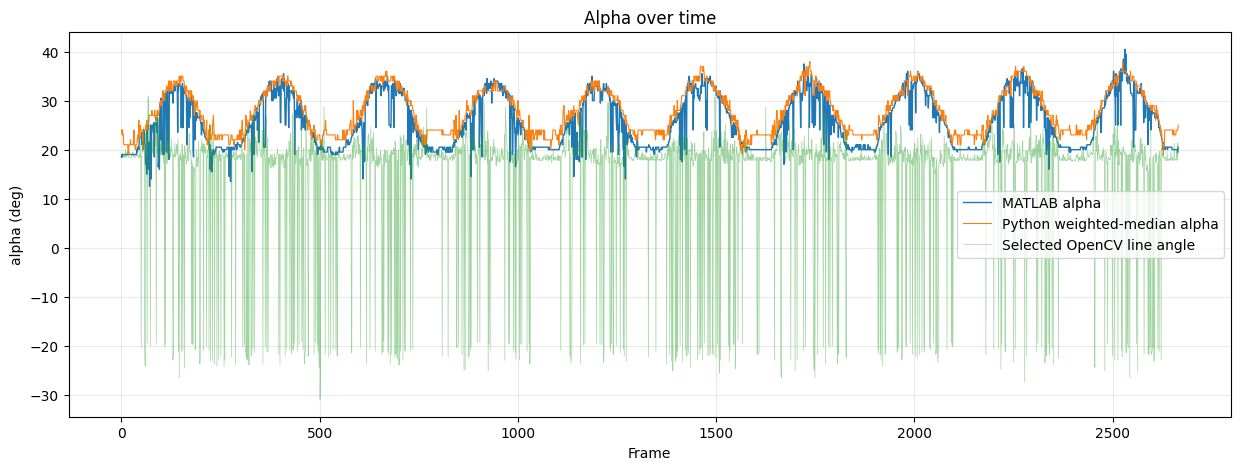

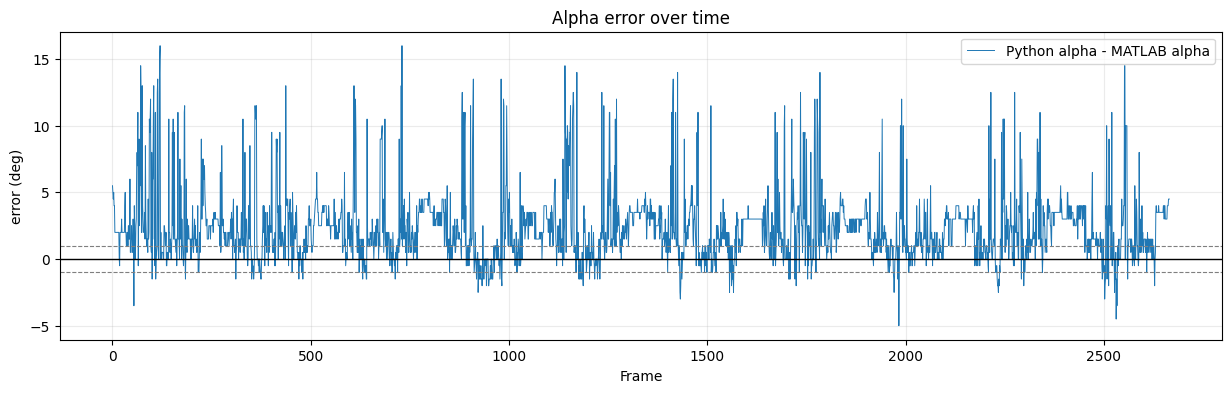

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(frames, mat_alpha, linewidth=1.0, label="MATLAB alpha")
ax.plot(frames, py_alpha, linewidth=0.8, label="Python weighted-median alpha")
ax.plot(frames, selected_line_alpha, linewidth=0.5, alpha=0.45, label="Selected OpenCV line angle")
ax.set_xlabel("Frame")
ax.set_ylabel("alpha (deg)")
ax.set_title("Alpha over time")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(frames, alpha_error, linewidth=0.7, label="Python alpha - MATLAB alpha")
ax.axhline(0, color="black", linewidth=1)
ax.axhline(1, color="tab:gray", linewidth=0.8, linestyle="--")
ax.axhline(-1, color="tab:gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Frame")
ax.set_ylabel("error (deg)")
ax.set_title("Alpha error over time")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

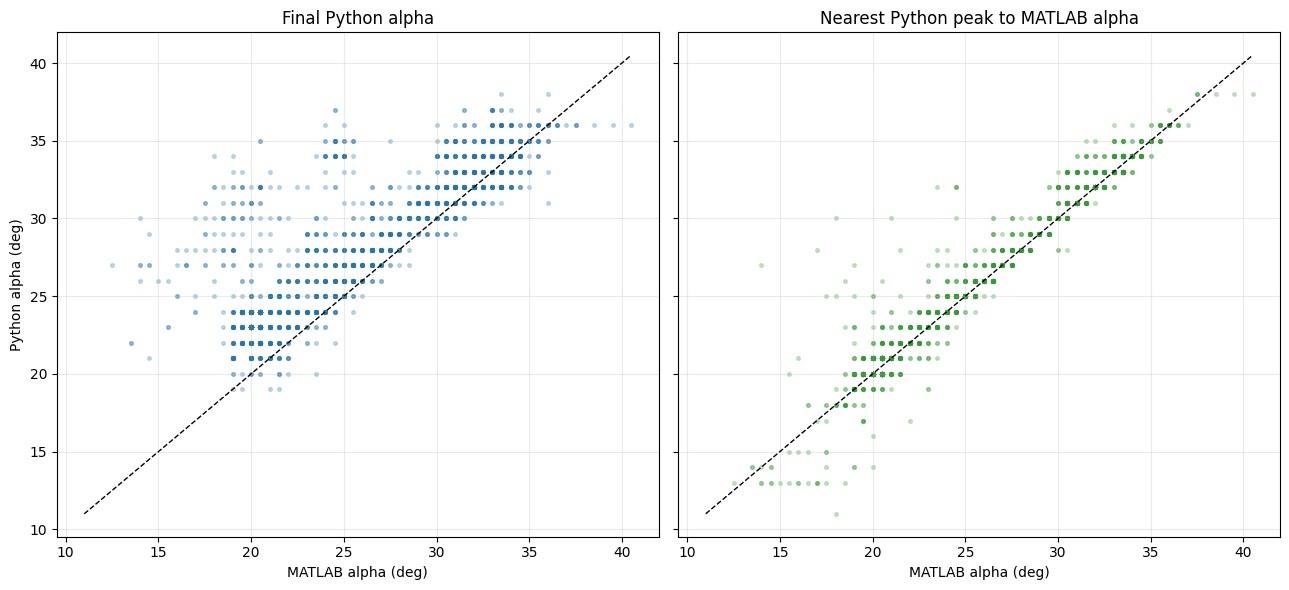

In [8]:
finite = np.isfinite(mat_alpha) & np.isfinite(py_alpha)
lo = float(np.nanmin([np.nanmin(mat_alpha), np.nanmin(py_alpha), np.nanmin(py_nearest_to_mat)]))
hi = float(np.nanmax([np.nanmax(mat_alpha), np.nanmax(py_alpha), np.nanmax(py_nearest_to_mat)]))

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
axes[0].scatter(mat_alpha[finite], py_alpha[finite], s=7, alpha=0.25)
axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[0].set_title("Final Python alpha")
axes[0].set_xlabel("MATLAB alpha (deg)")
axes[0].set_ylabel("Python alpha (deg)")
axes[0].grid(True, alpha=0.25)

finite2 = np.isfinite(mat_alpha) & np.isfinite(py_nearest_to_mat)
axes[1].scatter(mat_alpha[finite2], py_nearest_to_mat[finite2], s=7, alpha=0.25, color="tab:green")
axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
axes[1].set_title("Nearest Python peak to MATLAB alpha")
axes[1].set_xlabel("MATLAB alpha (deg)")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

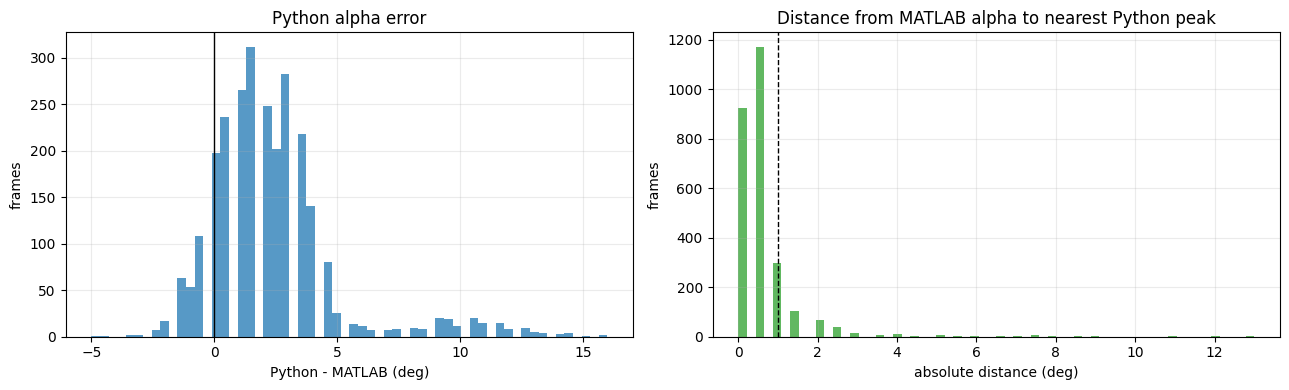

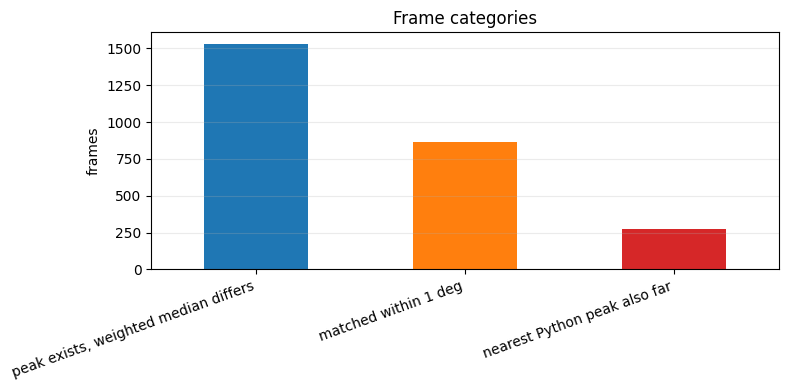

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(alpha_error[np.isfinite(alpha_error)], bins=60, color="tab:blue", alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Python alpha error")
axes[0].set_xlabel("Python - MATLAB (deg)")
axes[0].set_ylabel("frames")
axes[0].grid(True, alpha=0.25)

axes[1].hist(py_nearest_dist[np.isfinite(py_nearest_dist)], bins=60, color="tab:green", alpha=0.75)
axes[1].axvline(1, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Distance from MATLAB alpha to nearest Python peak")
axes[1].set_xlabel("absolute distance (deg)")
axes[1].set_ylabel("frames")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(category).value_counts().plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange", "tab:red", "tab:gray"])
ax.set_title("Frame categories")
ax.set_ylabel("frames")
ax.grid(True, axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. What variables move with the error?

These plots check whether large alpha error is associated with mask density, peak strength, peak spread, or the number of selected fascicle line candidates.

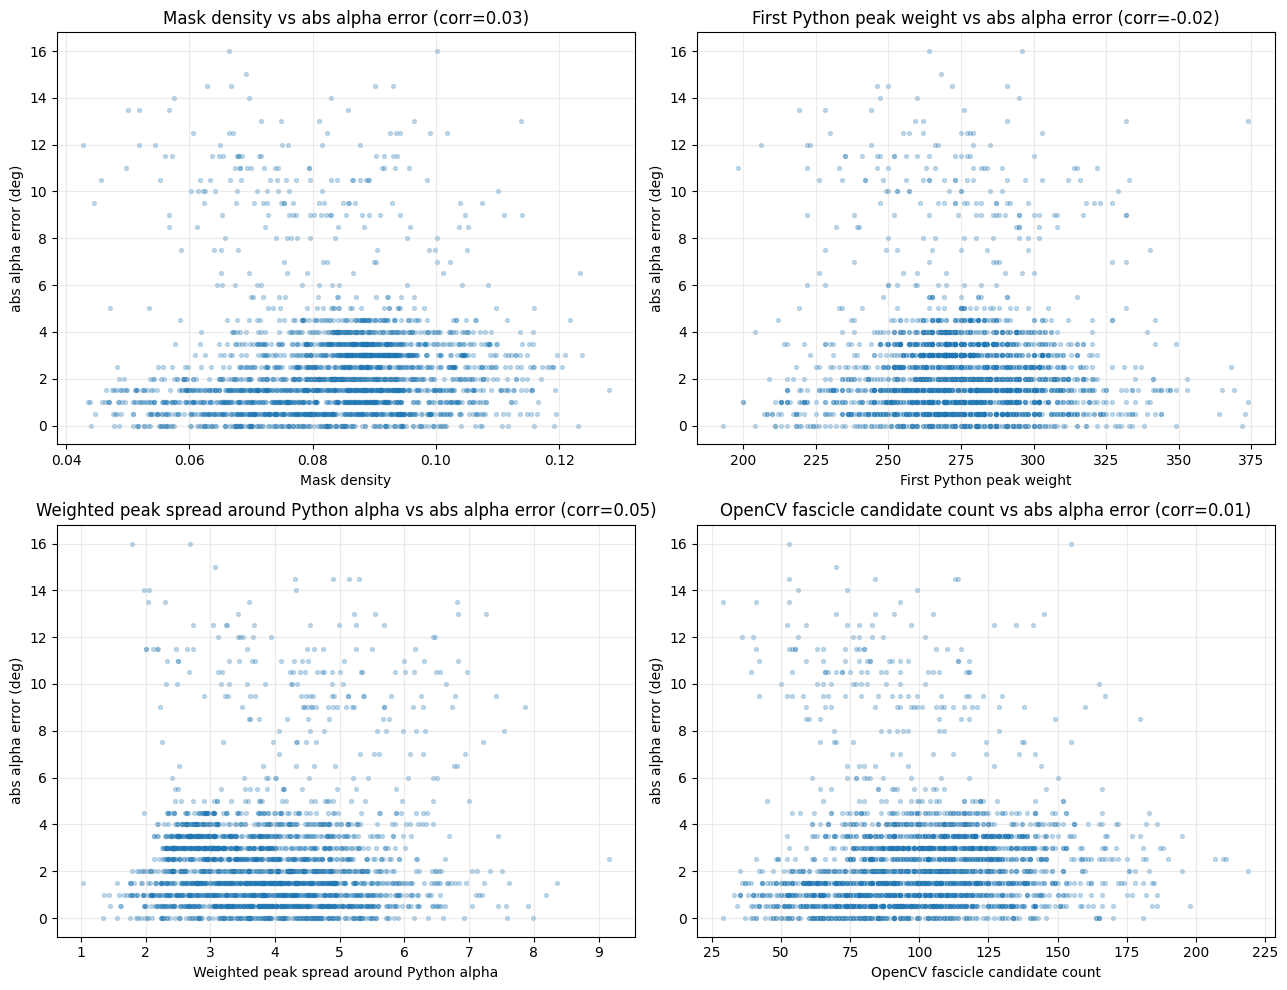

In [10]:
plot_df = diagnostics.replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

pairs = [
    ("mask_density", "Mask density"),
    ("py_first_peak_weight", "First Python peak weight"),
    ("py_weighted_peak_spread", "Weighted peak spread around Python alpha"),
    ("n_fascicle_candidates", "OpenCV fascicle candidate count"),
]

for ax, (col, title) in zip(axes, pairs):
    m = np.isfinite(plot_df[col]) & np.isfinite(plot_df["abs_alpha_error"])
    ax.scatter(plot_df.loc[m, col], plot_df.loc[m, "abs_alpha_error"], s=8, alpha=0.25)
    corr = np.corrcoef(plot_df.loc[m, col], plot_df.loc[m, "abs_alpha_error"])[0, 1] if m.sum() > 2 else np.nan
    ax.set_title(f"{title} vs abs alpha error (corr={corr:.2f})")
    ax.set_xlabel(title)
    ax.set_ylabel("abs alpha error (deg)")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Peak lists as signals

The next plot compares the stored MATLAB peak angles against the Python peak angles for the first ten Hough peaks. If the bands are similar but the weighted median is different, the issue is in peak weights/ranking/median behavior. If the bands themselves differ, the issue is in the mask or Hough accumulator input.

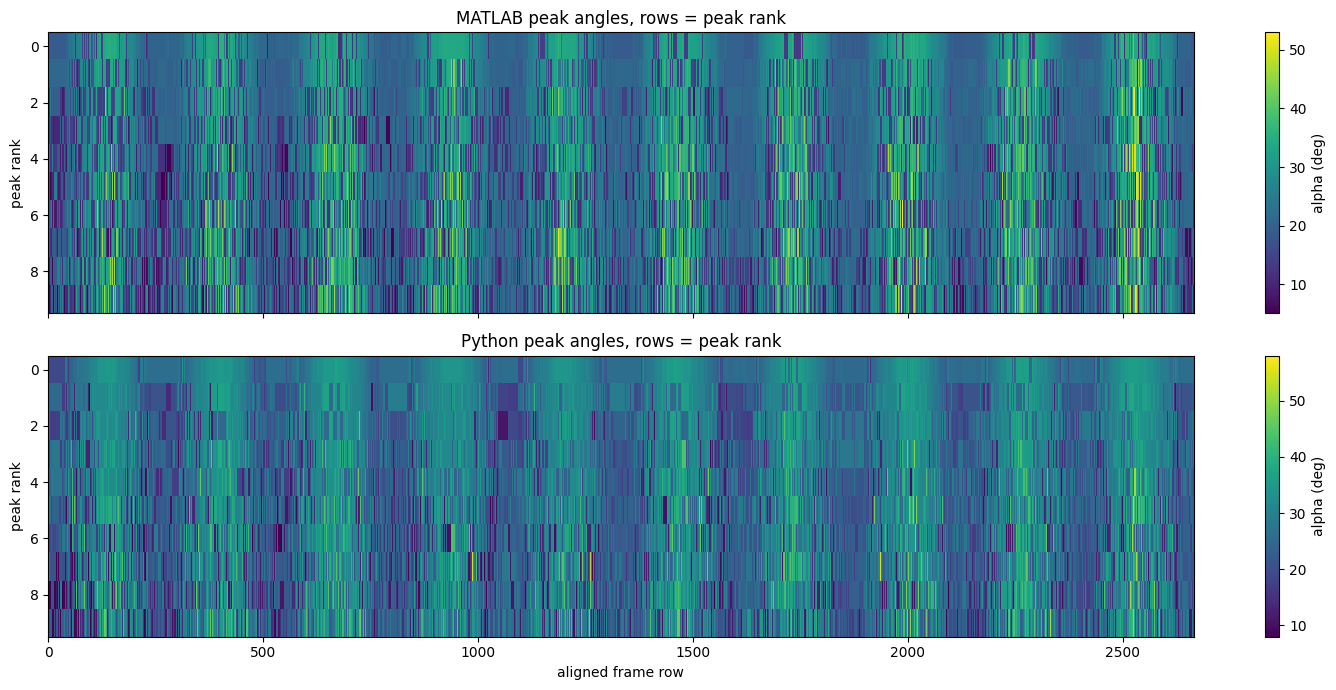

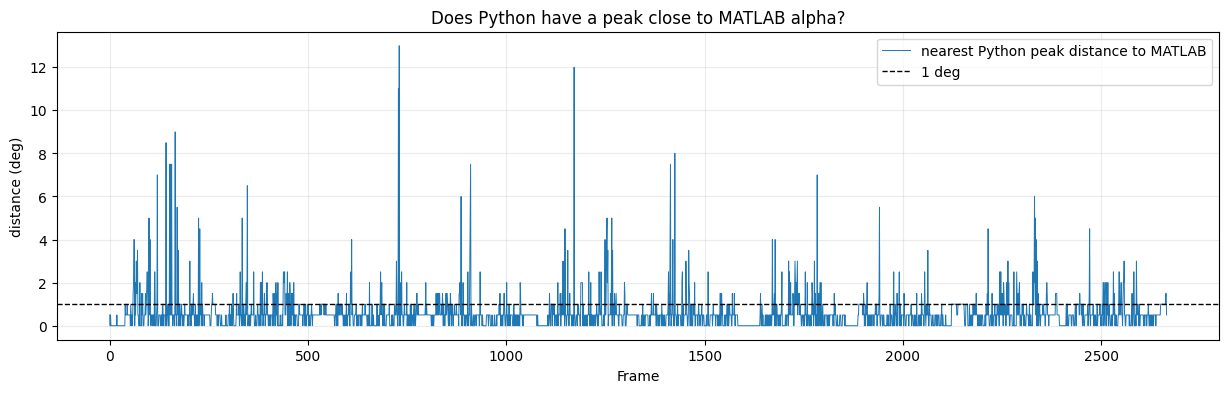

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

im0 = axes[0].imshow(mat_peak_alphas.T, aspect="auto", interpolation="nearest", cmap="viridis")
axes[0].set_title("MATLAB peak angles, rows = peak rank")
axes[0].set_ylabel("peak rank")
fig.colorbar(im0, ax=axes[0], label="alpha (deg)")

im1 = axes[1].imshow(py_peak_alphas.T, aspect="auto", interpolation="nearest", cmap="viridis")
axes[1].set_title("Python peak angles, rows = peak rank")
axes[1].set_ylabel("peak rank")
axes[1].set_xlabel("aligned frame row")
fig.colorbar(im1, ax=axes[1], label="alpha (deg)")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(frames, py_nearest_dist, linewidth=0.7, label="nearest Python peak distance to MATLAB")
ax.axhline(1, color="black", linewidth=1, linestyle="--", label="1 deg")
ax.set_xlabel("Frame")
ax.set_ylabel("distance (deg)")
ax.set_title("Does Python have a peak close to MATLAB alpha?")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## 8. Inspect representative frames

For a small set of frames, recompute the current Python Frangi mask and Hough profile. This is only for visualization; the sequence-level metrics above use the saved notebook 23 arrays.

The Hough profile plot compares:

- MATLAB alpha,
- Python notebook 23 alpha,
- recomputed 1-degree `dohough` alpha on the current mask,
- recomputed 0.5-degree `dohough` alpha on the same current mask.

If the 0.5-degree alpha moves closer only a little, resolution is a small contributor. If the whole profile peak is shifted, the mask pipeline is the next target.

In [12]:
fas_frangi_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.08,
    angle_min=10,
    angle_max=70,
    hough_threshold=15,
    min_line_length=25,
    max_line_gap=15,
)

base_dohough_params = DoHoughParams(
    angle_range=(8.0, 80.0),
    thetares=1.0,
    rhores=1.0,
    emask_radius=(rois["fascicle"][3] / 2.0, rois["fascicle"][2] / 2.0),
    npeaks=10,
    replace_diagonal_bias=True,
)

half_degree_dohough_params = DoHoughParams(
    angle_range=(8.0, 80.0),
    thetares=0.5,
    rhores=1.0,
    emask_radius=(rois["fascicle"][3] / 2.0, rois["fascicle"][2] / 2.0),
    npeaks=10,
    replace_diagonal_bias=True,
)


def read_gray_frame(video_path, frame_number):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_number))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read frame {frame_number}")
    if frame.ndim == 3:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return frame.copy()


def sort_profile(gamma, values):
    gamma = np.asarray(gamma, dtype=float)
    values = np.asarray(values, dtype=float)
    order = np.argsort(gamma)
    return gamma[order], values[order]

worst_rows = diagnostics.sort_values("abs_alpha_error", ascending=False).head(3)["row"].tolist()
weighted_rows = diagnostics.query("category == 'peak exists, weighted median differs'").sort_values("abs_alpha_error", ascending=False).head(2)["row"].tolist()
missing_rows = diagnostics.query("category == 'nearest Python peak also far'").sort_values("abs_alpha_error", ascending=False).head(2)["row"].tolist()
good_rows = diagnostics.sort_values("abs_alpha_error", ascending=True).head(1)["row"].tolist()

example_rows = []
for row in worst_rows + weighted_rows + missing_rows + good_rows:
    if int(row) not in example_rows:
        example_rows.append(int(row))
example_rows = example_rows[:6]

print("Example rows:", example_rows)
display(diagnostics.loc[example_rows, [
    "row", "frame", "category", "matlab_alpha", "python_alpha", "abs_alpha_error",
    "py_nearest_peak_to_matlab", "py_nearest_peak_distance_to_matlab", "mask_density"
]])

Example rows: [120, 730, 119, 2553, 1698]


,row,frame,category,matlab_alpha,python_alpha,abs_alpha_error,py_nearest_peak_to_matlab,py_nearest_peak_distance_to_matlab,mask_density
120,120,120,nearest Python peak also far,18.0,34.0,16.0,25.0,7.0,0.066404
730,730,730,nearest Python peak also far,14.0,30.0,16.0,27.0,13.0,0.100177
119,119,119,"peak exists, weighted median differs",19.0,34.0,15.0,20.0,1.0,0.069132
2553,2553,2553,"peak exists, weighted median differs",20.5,35.0,14.5,20.0,0.5,0.062889
1698,1698,1698,matched within 1 deg,32.0,32.0,0.0,32.0,0.0,0.063598


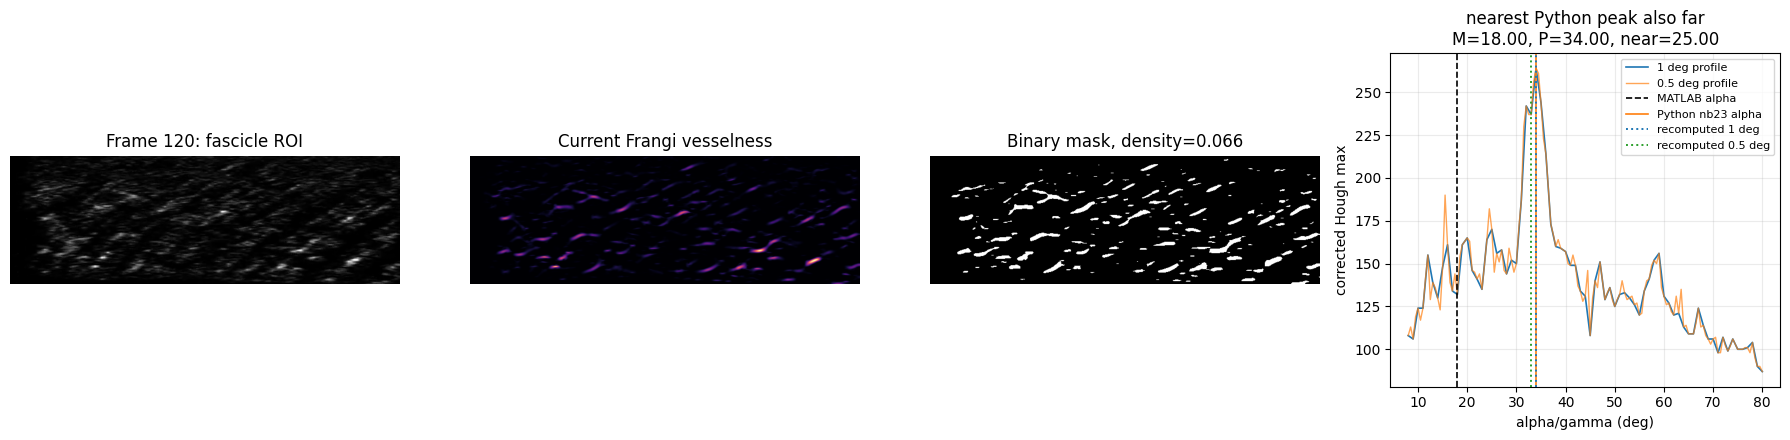

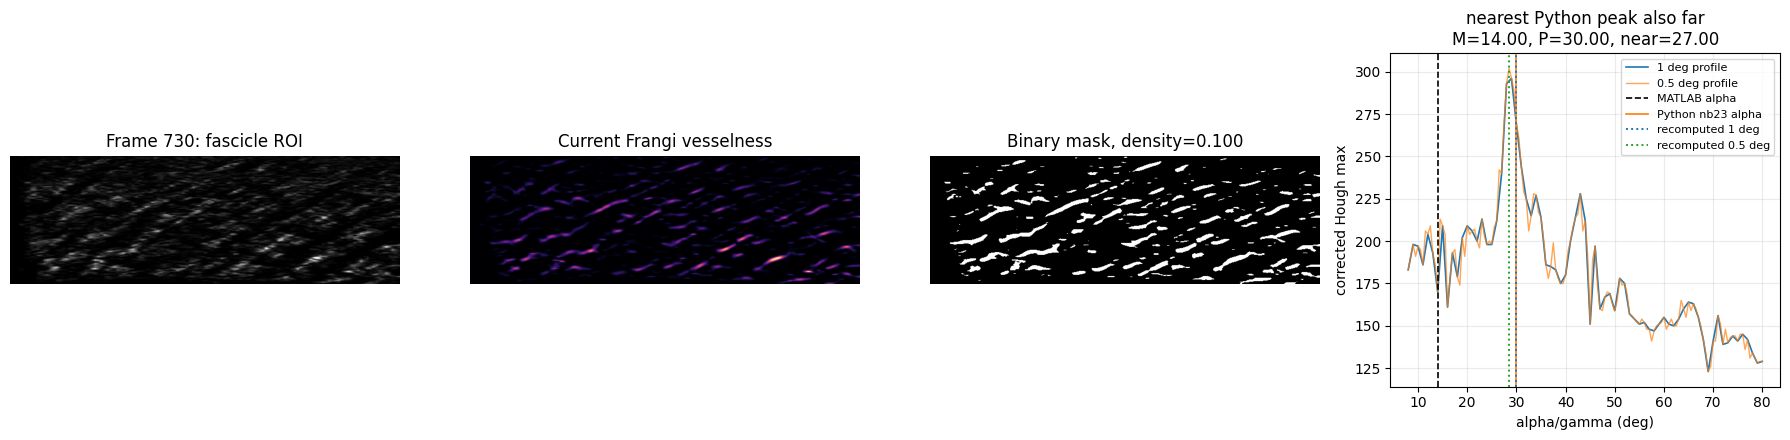

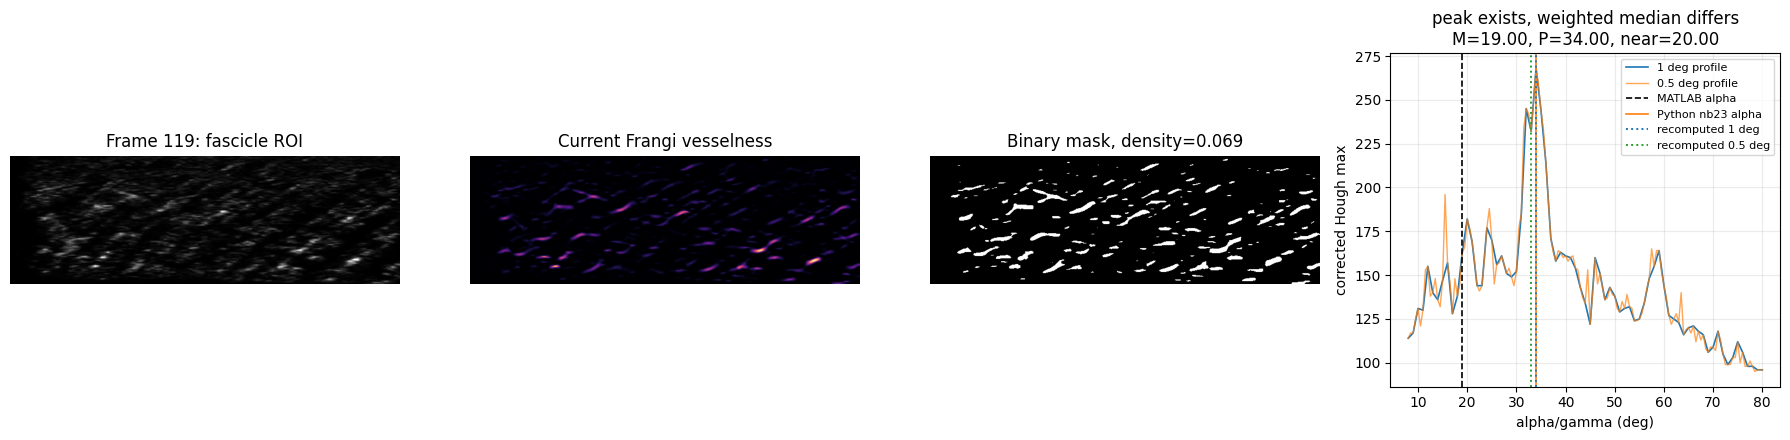

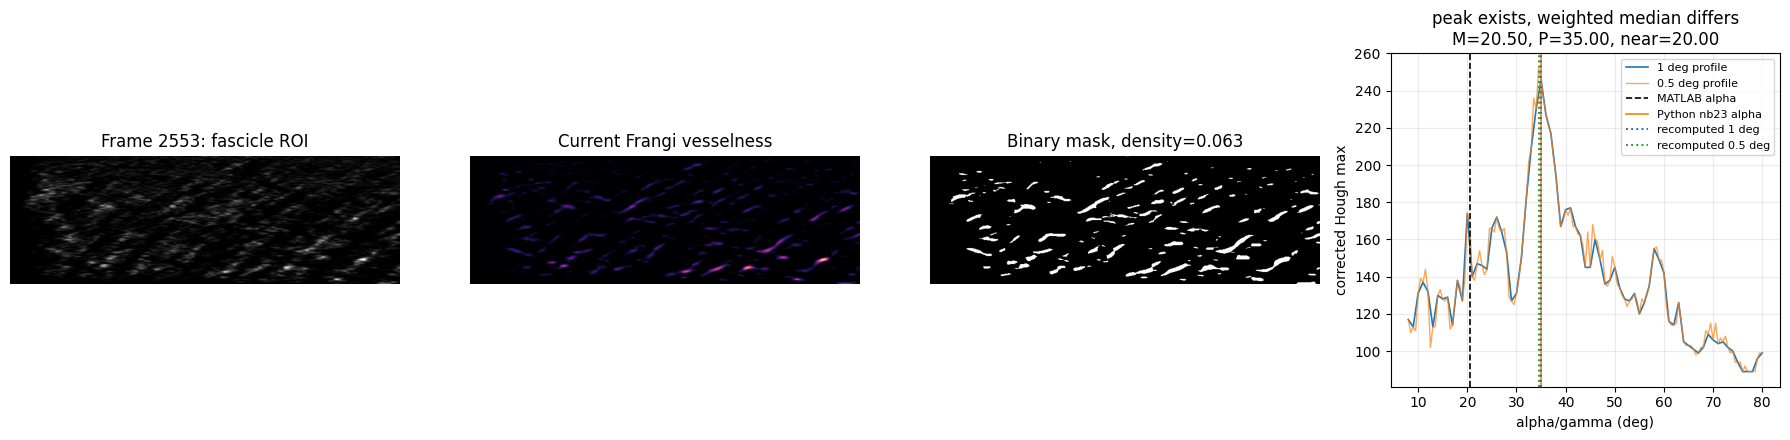

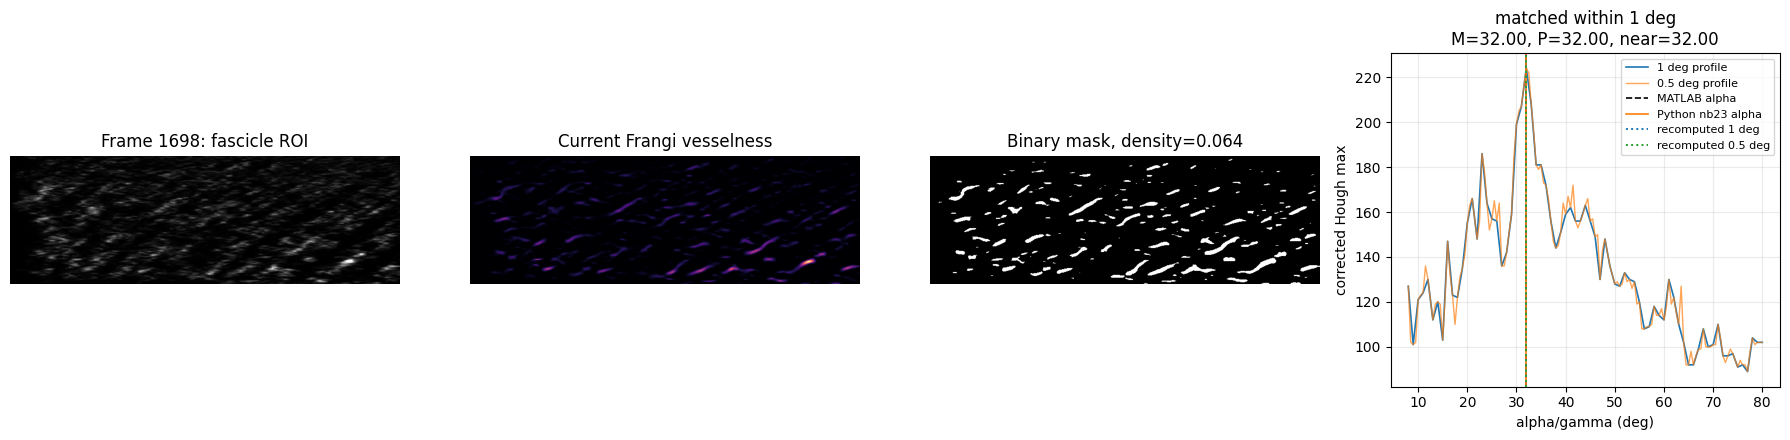

In [13]:
for row_idx in example_rows:
    frame_number = int(frames[row_idx])
    frame_gray = read_gray_frame(VIDEO_PATH, frame_number)
    fas_img = roi.extract_roi(frame_gray, rois["fascicle"])

    vesselness = fas_frangi_detector.get_vesselness_map(fas_img)
    binary = vesselness >= fas_frangi_detector.threshold

    h1 = dohough(binary, base_dohough_params)
    h05 = dohough(binary, half_degree_dohough_params)
    gamma1, profile1 = sort_profile(h1["gamma"], h1["h_by_angle"])
    gamma05, profile05 = sort_profile(h05["gamma"], h05["h_by_angle"])

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    axes[0].imshow(fas_img, cmap="gray")
    axes[0].set_title(f"Frame {frame_number}: fascicle ROI")
    axes[0].axis("off")

    axes[1].imshow(vesselness, cmap="magma")
    axes[1].set_title("Current Frangi vesselness")
    axes[1].axis("off")

    axes[2].imshow(binary, cmap="gray")
    axes[2].set_title(f"Binary mask, density={binary.mean():.3f}")
    axes[2].axis("off")

    axes[3].plot(gamma1, profile1, label="1 deg profile", linewidth=1.2)
    axes[3].plot(gamma05, profile05, label="0.5 deg profile", linewidth=1.0, alpha=0.7)
    axes[3].axvline(mat_alpha[row_idx], color="black", linestyle="--", linewidth=1.2, label="MATLAB alpha")
    axes[3].axvline(py_alpha[row_idx], color="tab:orange", linestyle="-", linewidth=1.2, label="Python nb23 alpha")
    axes[3].axvline(h1["alpha"], color="tab:blue", linestyle=":", linewidth=1.4, label="recomputed 1 deg")
    axes[3].axvline(h05["alpha"], color="tab:green", linestyle=":", linewidth=1.4, label="recomputed 0.5 deg")
    axes[3].set_xlabel("alpha/gamma (deg)")
    axes[3].set_ylabel("corrected Hough max")
    axes[3].set_title(
        f"{diagnostics.loc[row_idx, 'category']}\n"
        f"M={mat_alpha[row_idx]:.2f}, P={py_alpha[row_idx]:.2f}, near={py_nearest_to_mat[row_idx]:.2f}"
    )
    axes[3].grid(True, alpha=0.25)
    axes[3].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 9. Notebook 25 conclusion and next step

Use the cells above to decide the next correction:

- If the nearest Python peak is close to MATLAB in most frames, but the final alpha is biased, inspect the exact `houghpeaks` suppression, peak weights, and `weightedMedian` flatten/sort behavior.
- If the nearest Python peak is far in the bad frames, the next correction is the MATLAB fascicle mask pipeline before changing geometry again.
- Because MATLAB peak angles often include half-degree values and Python notebook 23 used integer-degree bins, test `thetares=0.5` in a controlled notebook before changing the package default.

My current reading: the right Python peak is often already present, so the next notebook should focus on **why the current peak weights make the weighted median choose a higher alpha**, while also testing `thetares=0.5` on a small sequence sample.